# COMP9517 — Deep Learning Results Analysis

这个 Notebook **不再训练模型**，只读取 E1–E4 已经保存的结果文件，完成：

1. 汇总四个实验的最终指标；
2. 绘制训练/验证曲线；
3. 做 E1 vs E2（迁移学习）、E2 vs E3（数据增强）、E3 vs E4（网络架构）比较；
4. 对最佳模型 E4 做 confusion / hardest classes / most-confused pairs；
5. 从测试集中恢复并显示 successful results 与 failed results；
6. 导出报告可直接使用的 PNG / CSV 表格。

> 你之前训练时没有自动保存“成功/失败图片”，但 `predictions.csv` 已经保存了每张测试图片的真实标签和预测标签。  
> 因为测试 DataLoader 使用 `shuffle=False`，predictions 的行顺序与 `ImageFolder` 的测试图片顺序一致，所以我们可以重新从 test 目录读取图片并显示正确/错误案例，无需重新训练。

## 0. 路径设置

你有两种运行环境：

### Windows 本地
结果目录：
`D:\UNSW26T2\COMP9517\Project\deep_learning_results`

### Google Colab
结果目录：
`/content/drive/MyDrive/COMP9517/deep_learning_results`

请把 `USE_COLAB` 改成对应值。

另外需要填写 `TEST_DIR`。它必须指向你的测试集目录，结构应类似：

```text
test/
├── class001/
├── class002/
└── ...
```

如果你暂时只想分析 CSV/JSON，不看 successful/failed 图片，可以先不改 `TEST_DIR`。

In [1]:
from pathlib import Path
import json
import os
import math
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

USE_COLAB = True

if USE_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    RESULTS_DIR = Path("/content/drive/MyDrive/COMP9517/deep_learning_results")

    # TODO: 按你的 Colab 实际路径修改
    TEST_DIR = Path("/content/dataset/test")
else:
    RESULTS_DIR = Path(r"D:\UNSW26T2\COMP9517\Project\deep_learning_results")

    # TODO: 按你的 Windows 实际路径修改
    TEST_DIR = Path(r"D:\UNSW26T2\COMP9517\Project\dataset\test")

FIGURE_DIR = RESULTS_DIR / "analysis_figures"
TABLE_DIR = RESULTS_DIR / "analysis_tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("RESULTS_DIR:", RESULTS_DIR)
print("Exists:", RESULTS_DIR.exists())
print("TEST_DIR:", TEST_DIR)
print("TEST_DIR exists:", TEST_DIR.exists())

Mounted at /content/drive
RESULTS_DIR: /content/drive/MyDrive/COMP9517/deep_learning_results
Exists: True
TEST_DIR: /content/dataset/test
TEST_DIR exists: False


## 1. 定义四个实验

这四组实验分别用于三个主要 ablation：

- **E1 vs E2**：training from scratch vs transfer learning；
- **E2 vs E3**：basic vs strong augmentation；
- **E3 vs E4**：ResNet-18 vs EfficientNet-B0。

In [2]:
EXPERIMENTS = {
    "E1": "E1_resnet18_scratch_basic",
    "E2": "E2_resnet18_pretrained_basic",
    "E3": "E3_resnet18_pretrained_strong",
    "E4": "E4_efficientnet_b0_pretrained_strong",
}

EXPERIMENTS

{'E1': 'E1_resnet18_scratch_basic',
 'E2': 'E2_resnet18_pretrained_basic',
 'E3': 'E3_resnet18_pretrained_strong',
 'E4': 'E4_efficientnet_b0_pretrained_strong'}

## 2. 自动读取 metrics / history / predictions / config

代码兼容你当前“所有文件都直接放在 deep_learning_results 目录”的保存方式。

In [3]:
def find_result_file(experiment_name, suffix):
    # 例如：
    # experiment_name = E4_efficientnet_b0_pretrained_strong
    # suffix = metrics.json

    direct = RESULTS_DIR / f"{experiment_name}_{suffix}"

    if direct.exists():
        return direct

    # 如果以后改成每个实验一个子目录，也尝试递归寻找
    matches = list(RESULTS_DIR.rglob(f"{experiment_name}_{suffix}"))

    if matches:
        return matches[0]

    # 兼容子目录中使用简短文件名（metrics.json 等）
    experiment_dir = RESULTS_DIR / experiment_name
    short = experiment_dir / suffix

    if short.exists():
        return short

    return None


results = {}

for key, name in EXPERIMENTS.items():
    files = {
        "metrics": find_result_file(name, "metrics.json"),
        "history": find_result_file(name, "history.csv"),
        "predictions": find_result_file(name, "predictions.csv"),
        "config": find_result_file(name, "config.json"),
        "checkpoint": find_result_file(name, "best.pt"),
    }

    results[key] = files

    print(f"\n{key}: {name}")
    for file_type, path in files.items():
        print(f"  {file_type:12s}: {path}")


E1: E1_resnet18_scratch_basic
  metrics     : /content/drive/MyDrive/COMP9517/deep_learning_results/E1_resnet18_scratch_basic_metrics.json
  history     : /content/drive/MyDrive/COMP9517/deep_learning_results/E1_resnet18_scratch_basic_history.csv
  predictions : /content/drive/MyDrive/COMP9517/deep_learning_results/E1_resnet18_scratch_basic_predictions.csv
  config      : /content/drive/MyDrive/COMP9517/deep_learning_results/E1_resnet18_scratch_basic_config.json
  checkpoint  : /content/drive/MyDrive/COMP9517/deep_learning_results/E1_resnet18_scratch_basic_best.pt

E2: E2_resnet18_pretrained_basic
  metrics     : /content/drive/MyDrive/COMP9517/deep_learning_results/E2_resnet18_pretrained_basic_metrics.json
  history     : /content/drive/MyDrive/COMP9517/deep_learning_results/E2_resnet18_pretrained_basic_history.csv
  predictions : /content/drive/MyDrive/COMP9517/deep_learning_results/E2_resnet18_pretrained_basic_predictions.csv
  config      : /content/drive/MyDrive/COMP9517/deep_lea

## 3. 生成最终结果总表

这张表可以作为报告 Experimental Results 中主结果表的基础。

In [4]:
rows = []

for key, name in EXPERIMENTS.items():
    metrics_path = results[key]["metrics"]
    config_path = results[key]["config"]

    if metrics_path is None:
        print(f"跳过 {key}：找不到 metrics.json")
        continue

    with open(metrics_path, "r", encoding="utf-8") as f:
        m = json.load(f)

    config = {}
    if config_path is not None:
        with open(config_path, "r", encoding="utf-8") as f:
            config = json.load(f)

    rows.append({
        "Experiment": key,
        "Architecture": m.get("architecture", config.get("architecture")),
        "Pretrained": m.get("pretrained", config.get("pretrained")),
        "Augmentation": m.get("augmentation", config.get("augmentation")),
        "Top-1 (%)": 100 * m["top1_accuracy"],
        "Top-5 (%)": 100 * m["top5_accuracy"],
        "Macro Precision (%)": 100 * m["macro_precision"],
        "Macro Recall (%)": 100 * m["macro_recall"],
        "Macro F1 (%)": 100 * m["macro_f1"],
        "Best Val Macro F1 (%)": 100 * m["best_val_macro_f1"],
        "Training Time (min)": m["training_seconds"] / 60,
        "Inference Time (s)": m["inference_seconds"],
        "Images/s": m["images_per_second"],
        "Parameters (M)": m["total_parameters"] / 1e6,
        "Epochs": m["epochs_completed"],
    })

summary = pd.DataFrame(rows)
summary = summary.sort_values("Experiment").reset_index(drop=True)

summary.round(2)

,Experiment,Architecture,Pretrained,Augmentation,Top-1 (%),Top-5 (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Best Val Macro F1 (%),Training Time (min),Inference Time (s),Images/s,Parameters (M),Epochs
0,E1,resnet18,False,basic,32.08,56.32,34.22,32.08,31.62,31.54,60.48,28.51,175.35,11.43,25
1,E2,resnet18,True,basic,57.72,80.38,62.34,57.72,57.17,57.05,26.56,24.28,205.94,11.43,12
2,E3,resnet18,True,strong,56.36,79.74,61.32,56.36,55.42,54.59,43.69,25.20,198.39,11.43,12
3,E4,efficientnet_b0,True,strong,72.16,89.86,74.38,72.16,71.77,70.85,46.95,29.04,172.20,4.65,12


In [5]:
summary_path = TABLE_DIR / "deep_learning_main_results.csv"
summary.to_csv(summary_path, index=False)

print("Saved:", summary_path)

Saved: /content/drive/MyDrive/COMP9517/deep_learning_results/analysis_tables/deep_learning_main_results.csv


## 4. 绘制最终性能比较图

这里用三个最关键指标：

- Top-1；
- Top-5；
- Macro-F1。

报告里一般不需要把所有指标都画成图，表格负责完整数字，图负责突出主要趋势。

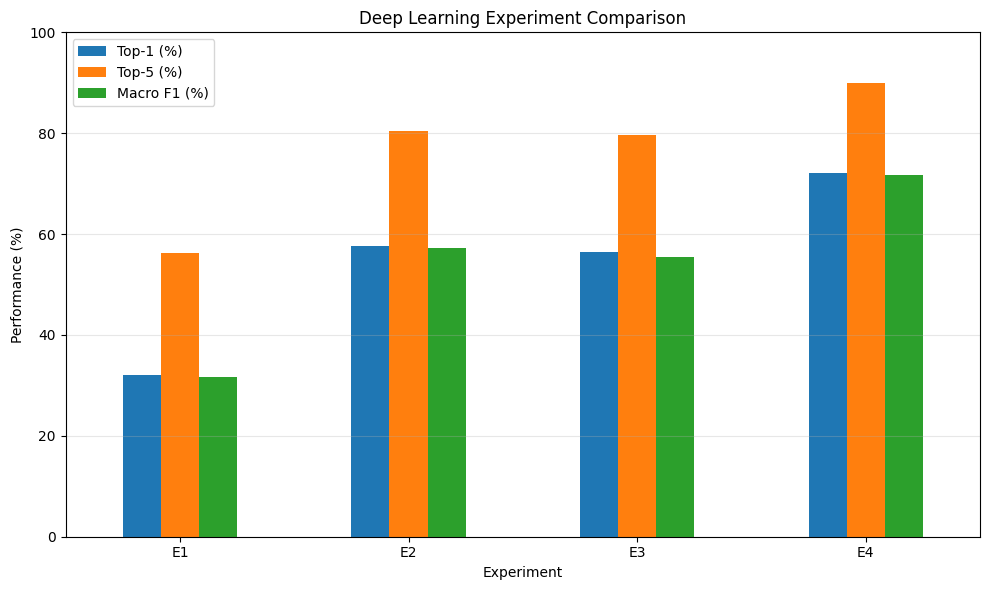

Saved: /content/drive/MyDrive/COMP9517/deep_learning_results/analysis_figures/main_performance_comparison.png


In [6]:
plot_df = summary.set_index("Experiment")[["Top-1 (%)", "Top-5 (%)", "Macro F1 (%)"]]

ax = plot_df.plot(kind="bar", figsize=(10, 6))
ax.set_ylabel("Performance (%)")
ax.set_title("Deep Learning Experiment Comparison")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()

path = FIGURE_DIR / "main_performance_comparison.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", path)

## 5. 读取每个实验的 training history

`history.csv` 保存了每个 epoch 的：

- train loss；
- validation loss；
- train accuracy；
- validation accuracy；
- validation macro-F1；
- learning rate；
- epoch 时间。

这些数据用于证明模型是否充分训练、是否收敛，以及是否过拟合。

In [7]:
histories = {}

for key, name in EXPERIMENTS.items():
    path = results[key]["history"]

    if path is None:
        print(f"Missing history for {key}")
        continue

    histories[key] = pd.read_csv(path)
    print(key, histories[key].shape)
    display(histories[key].head())

E1 (25, 9)


,epoch,learning_rate,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1,epoch_seconds
0,1,0.001,6.082922,0.00880,0.004897,5.905668,0.0174,0.004517,146.581259
1,2,0.001,5.715414,0.01690,0.010643,5.603385,0.0206,0.007301,141.217927
2,3,0.001,5.473986,0.03190,0.023092,5.437650,0.0372,0.019787,143.256523
3,4,0.001,5.257850,0.05270,0.039952,5.271830,0.0544,0.033467,141.321198
4,5,0.001,5.032804,0.07645,0.060836,5.073939,0.0726,0.047465,142.622870


E2 (12, 9)


,epoch,learning_rate,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1,epoch_seconds
0,1,0.0003,4.661140,0.19820,0.188180,3.715171,0.3372,0.307517,130.908717
1,2,0.0003,3.105850,0.47330,0.460769,3.142712,0.4488,0.435119,134.073535
2,3,0.0003,2.533618,0.60740,0.602383,2.917810,0.4962,0.486389,133.552381
3,4,0.0003,2.179018,0.69955,0.697256,2.896272,0.4978,0.492179,137.318504
4,5,0.0003,1.916764,0.77805,0.777378,2.792287,0.5226,0.521493,132.851279


E3 (12, 9)


,epoch,learning_rate,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1,epoch_seconds
0,1,0.0003,4.935639,0.14615,0.134574,3.894784,0.2918,0.260265,223.589107
1,2,0.0003,3.550051,0.36350,0.348291,3.424476,0.3732,0.353772,212.578484
2,3,0.0003,3.040219,0.47305,0.464279,3.070797,0.4536,0.446530,223.333835
3,4,0.0003,2.730601,0.54670,0.541663,2.980019,0.4828,0.475072,221.783506
4,5,0.0003,2.492709,0.60865,0.605264,2.872630,0.5098,0.502567,223.180033


E4 (12, 9)


,epoch,learning_rate,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1,epoch_seconds
0,1,0.0003,4.766169,0.1919,0.185335,3.112360,0.4664,0.435235,251.338033
1,2,0.0003,2.908622,0.5085,0.496979,2.492537,0.6022,0.591056,221.704580
2,3,0.0003,2.368798,0.6415,0.637456,2.310884,0.6412,0.631127,222.882441
3,4,0.0003,2.080528,0.7210,0.719478,2.210454,0.6656,0.659522,221.737710
4,5,0.0003,1.905645,0.7647,0.763729,2.164718,0.6918,0.684852,221.215203


## 6. 每个实验的 Train / Validation Accuracy 曲线

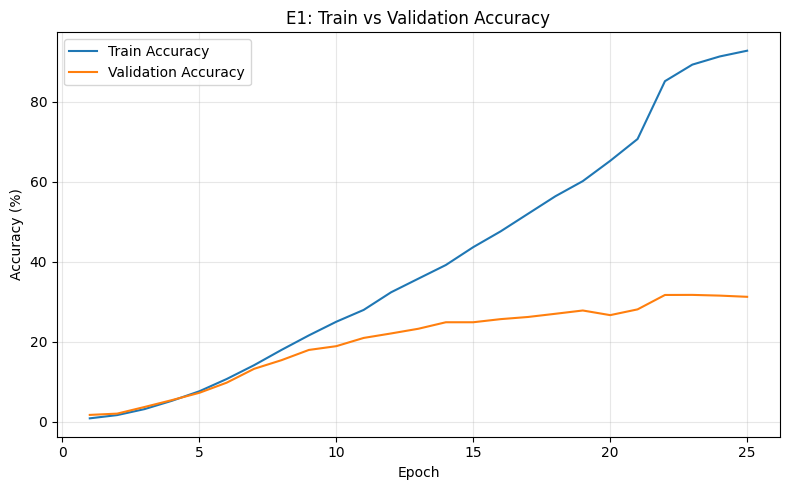

Saved: /content/drive/MyDrive/COMP9517/deep_learning_results/analysis_figures/E1_accuracy_curve.png


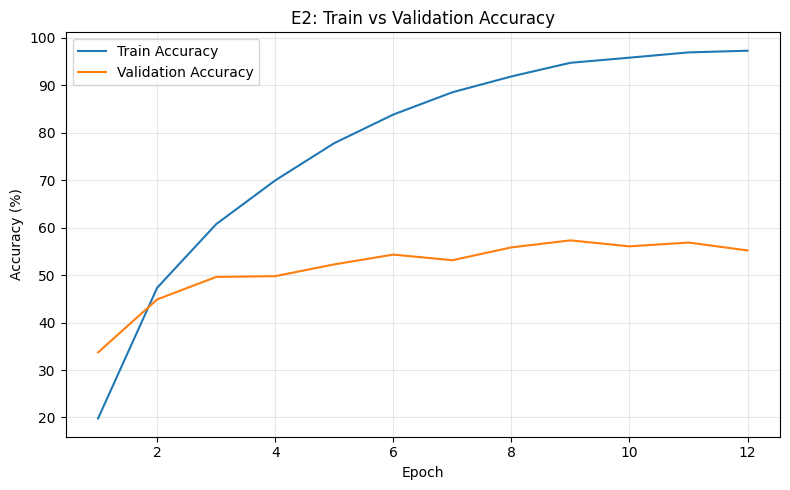

Saved: /content/drive/MyDrive/COMP9517/deep_learning_results/analysis_figures/E2_accuracy_curve.png


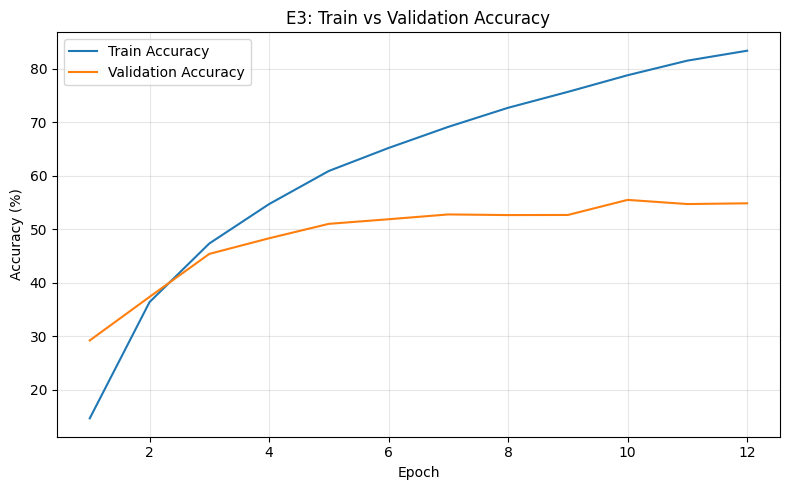

Saved: /content/drive/MyDrive/COMP9517/deep_learning_results/analysis_figures/E3_accuracy_curve.png


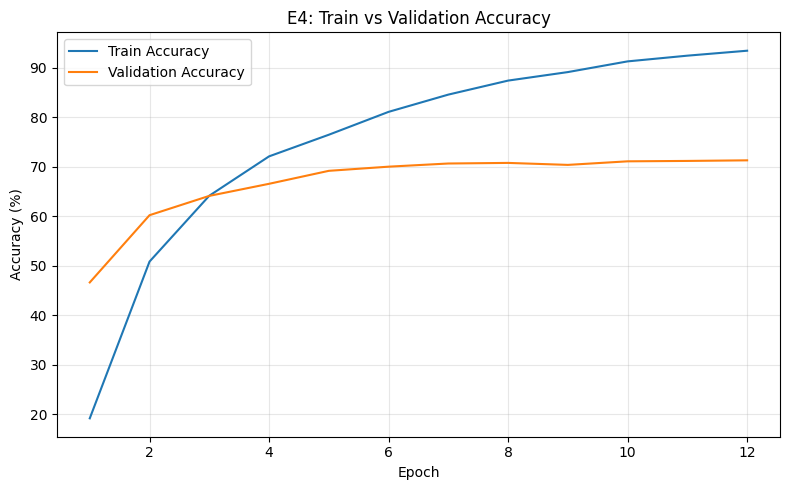

Saved: /content/drive/MyDrive/COMP9517/deep_learning_results/analysis_figures/E4_accuracy_curve.png


In [8]:
for key, df in histories.items():
    plt.figure(figsize=(8, 5))

    plt.plot(df["epoch"], df["train_accuracy"] * 100, label="Train Accuracy")
    plt.plot(df["epoch"], df["val_accuracy"] * 100, label="Validation Accuracy")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"{key}: Train vs Validation Accuracy")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    path = FIGURE_DIR / f"{key}_accuracy_curve.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", path)

## 7. 每个实验的 Loss 曲线

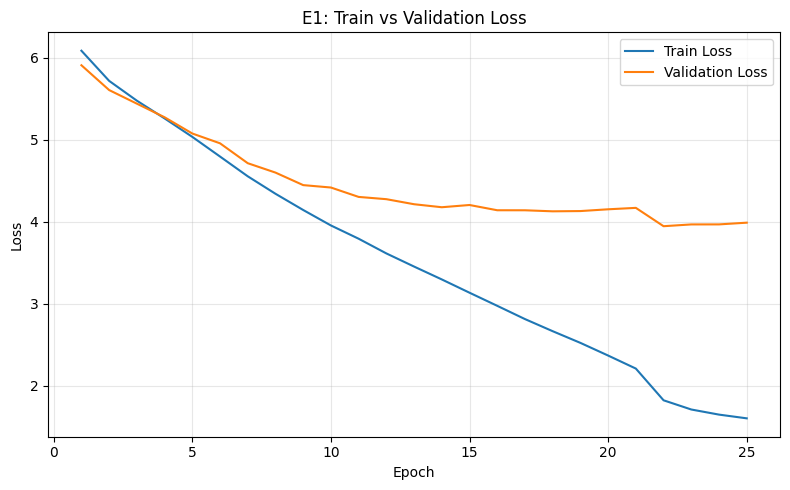

Saved: /content/drive/MyDrive/COMP9517/deep_learning_results/analysis_figures/E1_loss_curve.png


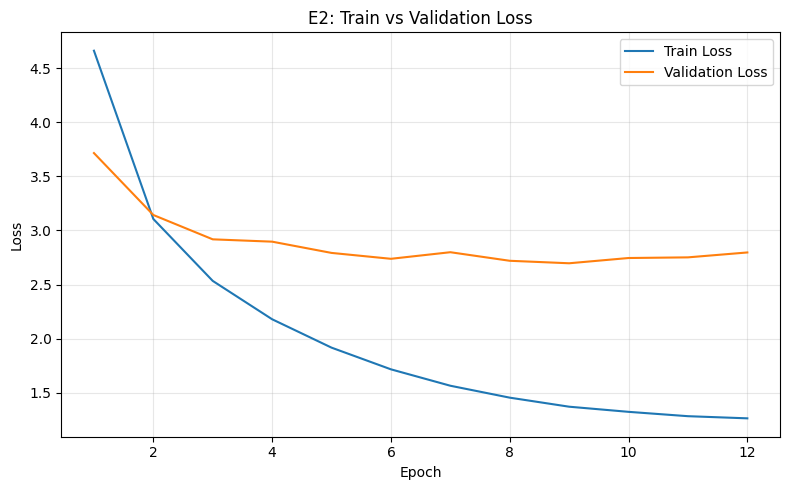

Saved: /content/drive/MyDrive/COMP9517/deep_learning_results/analysis_figures/E2_loss_curve.png


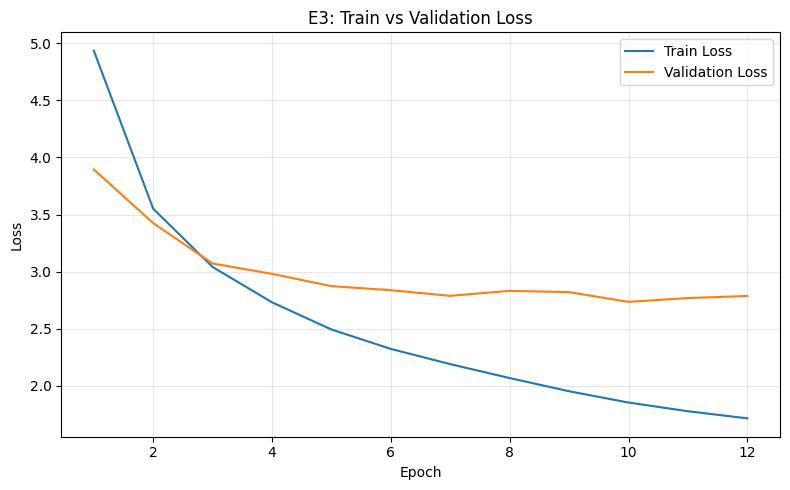

Saved: /content/drive/MyDrive/COMP9517/deep_learning_results/analysis_figures/E3_loss_curve.png


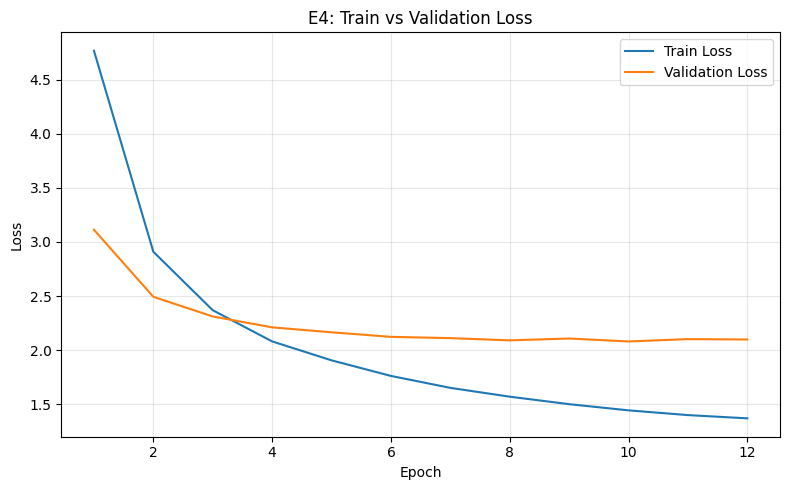

Saved: /content/drive/MyDrive/COMP9517/deep_learning_results/analysis_figures/E4_loss_curve.png


In [9]:
for key, df in histories.items():
    plt.figure(figsize=(8, 5))

    plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
    plt.plot(df["epoch"], df["val_loss"], label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{key}: Train vs Validation Loss")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    path = FIGURE_DIR / f"{key}_loss_curve.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", path)

## 8. 四个实验 Validation Macro-F1 同图比较

这张图非常适合报告，因为它直接展示不同实验的收敛速度和最终 validation performance。

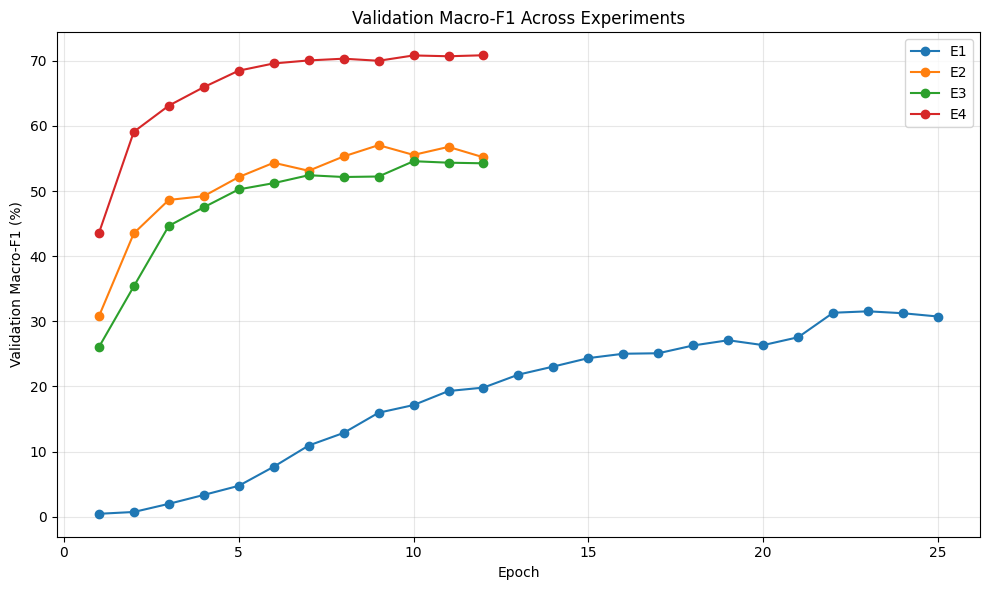

Saved: /content/drive/MyDrive/COMP9517/deep_learning_results/analysis_figures/validation_macro_f1_comparison.png


In [10]:
plt.figure(figsize=(10, 6))

for key, df in histories.items():
    plt.plot(
        df["epoch"],
        df["val_macro_f1"] * 100,
        marker="o",
        label=key,
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Macro-F1 (%)")
plt.title("Validation Macro-F1 Across Experiments")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

path = FIGURE_DIR / "validation_macro_f1_comparison.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", path)

## 9. 自动计算三个核心 Ablation 的提升/下降

用于写 Discussion 时避免手算出错。

In [11]:
def metric_row(exp):
    return summary.loc[summary["Experiment"] == exp].iloc[0]

def compare(exp_a, exp_b, title):
    a = metric_row(exp_a)
    b = metric_row(exp_b)

    print("=" * 70)
    print(title)
    print(f"{exp_a} -> {exp_b}")
    print(f"Top-1 change:    {b['Top-1 (%)'] - a['Top-1 (%)']:+.2f} percentage points")
    print(f"Top-5 change:    {b['Top-5 (%)'] - a['Top-5 (%)']:+.2f} percentage points")
    print(f"Macro-F1 change: {b['Macro F1 (%)'] - a['Macro F1 (%)']:+.2f} percentage points")
    print(f"Training time:   {a['Training Time (min)']:.2f} -> {b['Training Time (min)']:.2f} min")
    print(f"Parameters:      {a['Parameters (M)']:.2f} -> {b['Parameters (M)']:.2f} M")
    print()

compare("E1", "E2", "Transfer Learning: Scratch vs ImageNet Pretraining")
compare("E2", "E3", "Data Augmentation: Basic vs Strong")
compare("E3", "E4", "Architecture: ResNet-18 vs EfficientNet-B0")

Transfer Learning: Scratch vs ImageNet Pretraining
E1 -> E2
Top-1 change:    +25.64 percentage points
Top-5 change:    +24.06 percentage points
Macro-F1 change: +25.56 percentage points
Training time:   60.48 -> 26.56 min
Parameters:      11.43 -> 11.43 M

Data Augmentation: Basic vs Strong
E2 -> E3
Top-1 change:    -1.36 percentage points
Top-5 change:    -0.64 percentage points
Macro-F1 change: -1.76 percentage points
Training time:   26.56 -> 43.69 min
Parameters:      11.43 -> 11.43 M

Architecture: ResNet-18 vs EfficientNet-B0
E3 -> E4
Top-1 change:    +15.80 percentage points
Top-5 change:    +10.12 percentage points
Macro-F1 change: +16.35 percentage points
Training time:   43.69 -> 46.95 min
Parameters:      11.43 -> 4.65 M



# Error Analysis — 以最佳模型 E4 为主

下面开始分析：

1. 哪些类别最难；
2. 哪些类别最容易互相混淆；
3. confusion matrix；
4. successful / failed examples。

这部分不需要重新训练。

In [12]:
BEST_EXPERIMENT = "E4"

pred_path = results[BEST_EXPERIMENT]["predictions"]

if pred_path is None:
    raise FileNotFoundError("找不到 E4 predictions.csv")

pred_df = pd.read_csv(pred_path)
print(pred_df.columns.tolist())
print(pred_df.shape)

display(pred_df.head())

['target', 'prediction', 'target_name', 'prediction_name']
(5000, 4)


,target,prediction,target_name,prediction_name
0,0,16,0,16
1,0,0,0,0
2,0,0,0,0
3,0,80,0,80
4,0,27,0,27


## 10. Hardest classes

这里按照每个类别的 recall（该类别测试图中被正确识别的比例）排序。

由于每类测试图片数量相同，recall 很直观：

- 10 张测试图识别对 8 张 → recall = 80%；
- 10 张只识别对 2 张 → recall = 20%。

In [13]:
required_cols = {"target", "prediction"}

if not required_cols.issubset(pred_df.columns):
    raise ValueError(
        f"predictions.csv 至少需要 {required_cols}，"
        f"当前列是：{pred_df.columns.tolist()}"
    )

targets = pred_df["target"].to_numpy()
predictions = pred_df["prediction"].to_numpy()

class_ids = sorted(np.unique(targets))

class_rows = []

for class_id in class_ids:
    mask = targets == class_id
    total = mask.sum()
    correct = (predictions[mask] == class_id).sum()
    recall = correct / total if total else np.nan

    if "target_name" in pred_df.columns:
        class_name = pred_df.loc[mask, "target_name"].iloc[0]
    else:
        class_name = str(class_id)

    class_rows.append({
        "class_id": class_id,
        "class_name": class_name,
        "test_images": total,
        "correct": correct,
        "recall": recall,
    })

class_performance = pd.DataFrame(class_rows).sort_values(
    ["recall", "class_id"],
    ascending=[True, True],
)

hardest_path = TABLE_DIR / "E4_hardest_classes.csv"
class_performance.to_csv(hardest_path, index=False)

display(class_performance.head(20))
print("Saved:", hardest_path)

,class_id,class_name,test_images,correct,recall
160,160,160,10,1,0.1
187,187,187,10,1,0.1
370,370,370,10,1,0.1
383,383,383,10,1,0.1
395,395,395,10,1,0.1
402,402,402,10,1,0.1
7,7,7,10,2,0.2
162,162,162,10,2,0.2
225,225,225,10,2,0.2
241,241,241,10,2,0.2


Saved: /content/drive/MyDrive/COMP9517/deep_learning_results/analysis_tables/E4_hardest_classes.csv


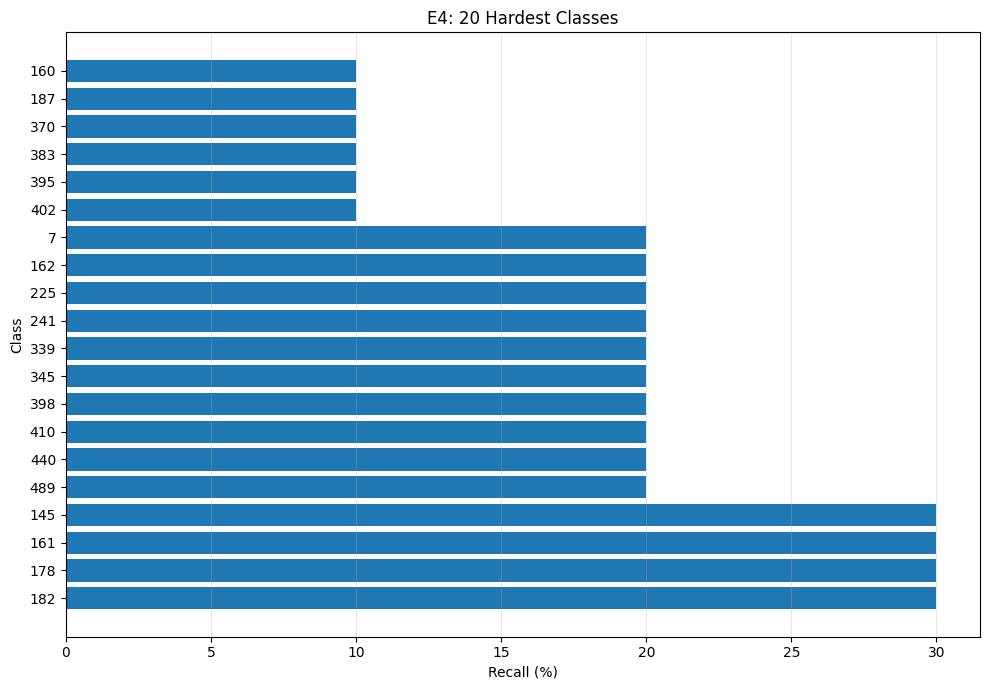

Saved: /content/drive/MyDrive/COMP9517/deep_learning_results/analysis_figures/E4_hardest_20_classes.png


In [14]:
hardest_20 = class_performance.head(20).copy()

plt.figure(figsize=(10, 7))
plt.barh(
    hardest_20["class_name"].astype(str),
    hardest_20["recall"] * 100
)
plt.xlabel("Recall (%)")
plt.ylabel("Class")
plt.title("E4: 20 Hardest Classes")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

path = FIGURE_DIR / "E4_hardest_20_classes.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", path)

## 11. Most-confused species pairs

统计最常见的：

`True class A -> Predicted class B`

只统计错误预测。

In [15]:
pair_counter = Counter()

for true_label, pred_label in zip(targets, predictions):
    if true_label != pred_label:
        pair_counter[(int(true_label), int(pred_label))] += 1

name_lookup = {}

if "target_name" in pred_df.columns:
    for _, row in pred_df[["target", "target_name"]].drop_duplicates().iterrows():
        name_lookup[int(row["target"])] = str(row["target_name"])

pair_rows = []

for (true_id, pred_id), count in pair_counter.most_common(50):
    pair_rows.append({
        "true_class_id": true_id,
        "true_class": name_lookup.get(true_id, str(true_id)),
        "predicted_class_id": pred_id,
        "predicted_class": name_lookup.get(pred_id, str(pred_id)),
        "count": count,
    })

confused_pairs = pd.DataFrame(pair_rows)

pairs_path = TABLE_DIR / "E4_most_confused_pairs.csv"
confused_pairs.to_csv(pairs_path, index=False)

display(confused_pairs.head(20))
print("Saved:", pairs_path)

,true_class_id,true_class,predicted_class_id,predicted_class,count
0,345,345,346,346,6
1,410,410,409,409,6
2,117,117,118,118,5
3,162,162,163,163,5
4,225,225,223,223,4
5,372,372,279,279,4
6,393,393,403,403,4
7,40,40,39,39,3
8,109,109,98,98,3
9,146,146,147,147,3


Saved: /content/drive/MyDrive/COMP9517/deep_learning_results/analysis_tables/E4_most_confused_pairs.csv


## 12. 全部 500 类 confusion matrix

完整 500×500 matrix 会非常密，因此它更适合作为整体模式图，而不是逐格阅读。
报告中建议同时展示后面的“局部 confusion matrix”。

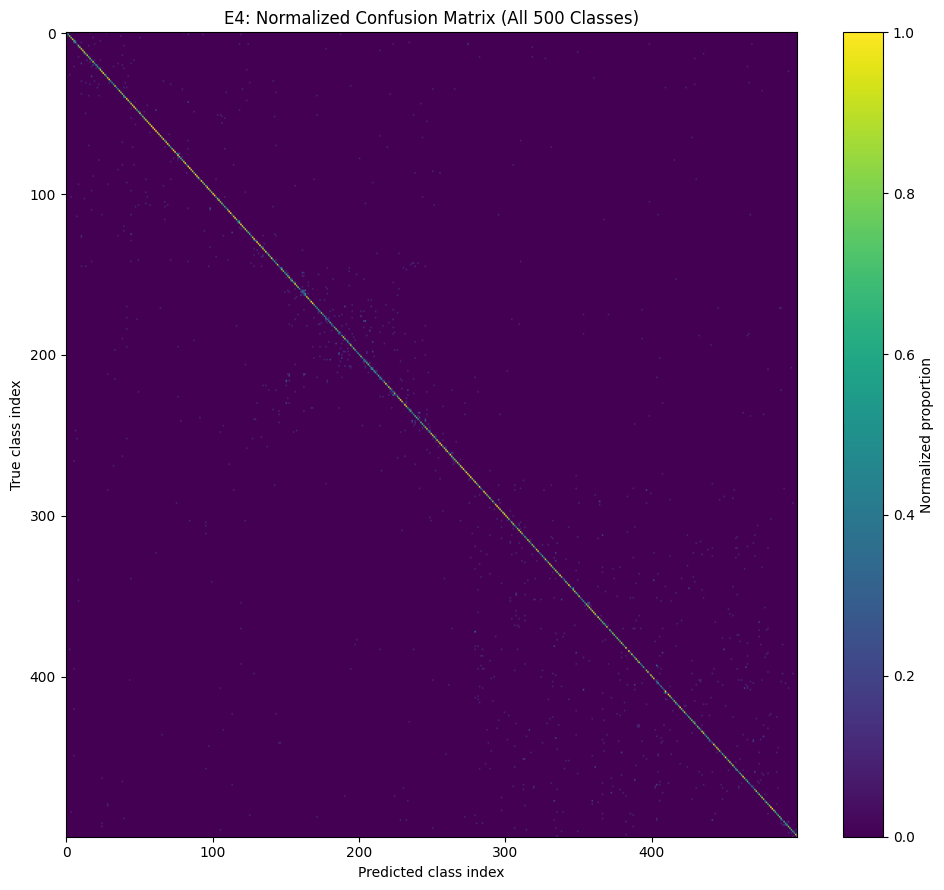

Saved: /content/drive/MyDrive/COMP9517/deep_learning_results/analysis_figures/E4_confusion_matrix_all_classes.png


In [16]:
cm = confusion_matrix(targets, predictions, labels=class_ids)

row_sums = cm.sum(axis=1, keepdims=True)
cm_normalized = np.divide(
    cm,
    row_sums,
    out=np.zeros_like(cm, dtype=float),
    where=row_sums != 0
)

plt.figure(figsize=(10, 9))
plt.imshow(cm_normalized, aspect="auto")
plt.colorbar(label="Normalized proportion")
plt.xlabel("Predicted class index")
plt.ylabel("True class index")
plt.title("E4: Normalized Confusion Matrix (All 500 Classes)")
plt.tight_layout()

path = FIGURE_DIR / "E4_confusion_matrix_all_classes.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", path)

## 13. 局部 confusion matrix

自动从最常混淆的错误对中选择最多 15 个类别，生成更容易阅读的局部矩阵。

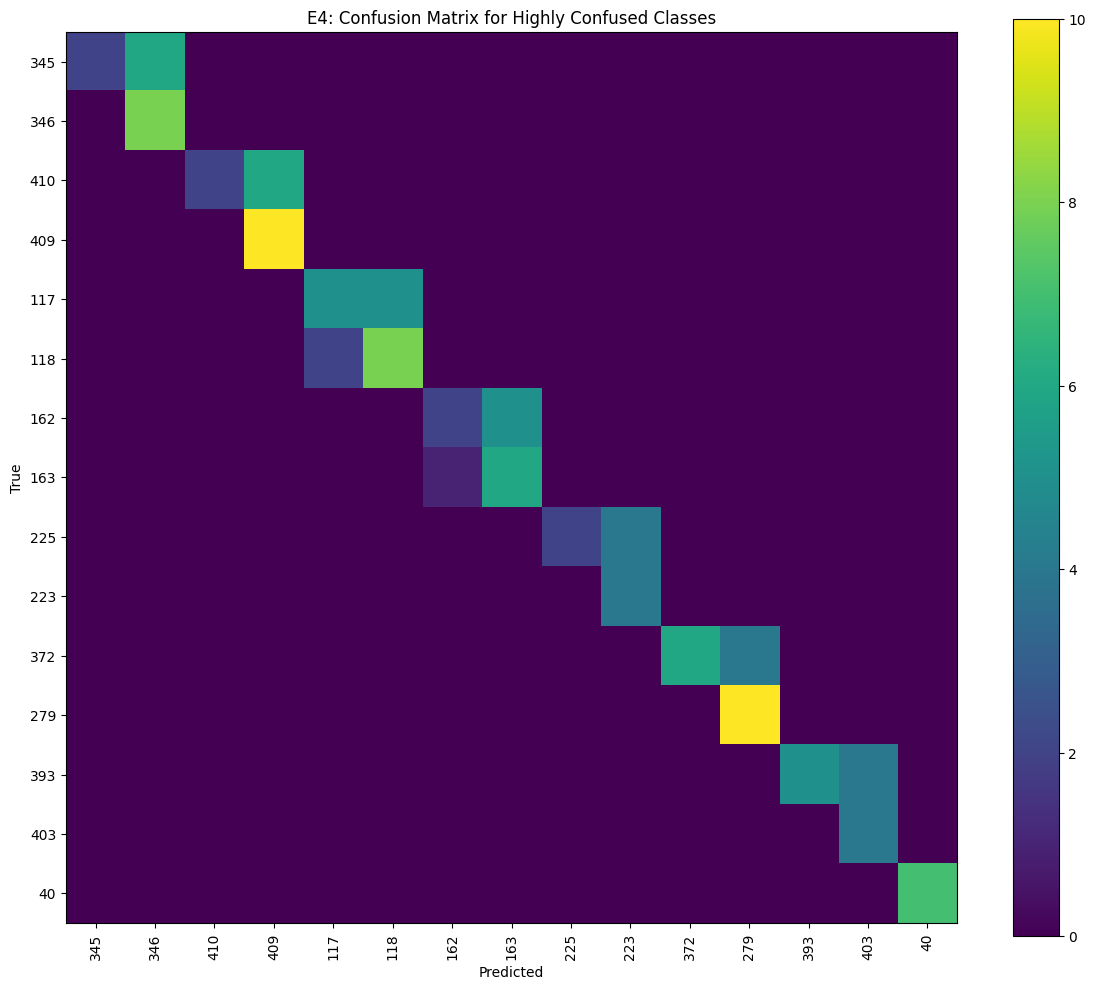

Selected classes: [345, 346, 410, 409, 117, 118, 162, 163, 225, 223, 372, 279, 393, 403, 40]
Saved: /content/drive/MyDrive/COMP9517/deep_learning_results/analysis_figures/E4_confusion_matrix_confused_subset.png


In [17]:
selected_ids = []

for _, row in confused_pairs.head(15).iterrows():
    for col in ["true_class_id", "predicted_class_id"]:
        class_id = int(row[col])

        if class_id not in selected_ids:
            selected_ids.append(class_id)

    if len(selected_ids) >= 15:
        break

selected_ids = selected_ids[:15]

mask = np.isin(targets, selected_ids) & np.isin(predictions, selected_ids)

local_cm = confusion_matrix(
    targets[mask],
    predictions[mask],
    labels=selected_ids,
)

labels = [name_lookup.get(i, str(i)) for i in selected_ids]

plt.figure(figsize=(12, 10))
plt.imshow(local_cm)
plt.colorbar()

plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("E4: Confusion Matrix for Highly Confused Classes")
plt.tight_layout()

path = FIGURE_DIR / "E4_confusion_matrix_confused_subset.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

print("Selected classes:", selected_ids)
print("Saved:", path)

# Successful / Failed Results 图片在哪里？

训练阶段没有自动把这些图片复制到结果目录，所以你之前只看到准确率是正常的。

它们本来还在 **test 数据集目录**。

我们现在利用：

1. `predictions.csv` 的每一行；
2. `ImageFolder` 测试集固定排序；
3. `shuffle=False` 的测试 DataLoader；

把预测结果重新对应回原始测试图片。

下面代码不会训练模型，只读取 test 图片。

In [18]:
from torchvision import datasets
from PIL import Image

if not TEST_DIR.exists():
    print(
        "TEST_DIR 不存在。\n"
        "请回到最上面的路径设置，把 TEST_DIR 改成你真实的 test 文件夹路径。"
    )
else:
    test_dataset_for_paths = datasets.ImageFolder(TEST_DIR)

    print("Test images:", len(test_dataset_for_paths))
    print("Prediction rows:", len(pred_df))

    if len(test_dataset_for_paths) != len(pred_df):
        print(
            "\n警告：测试集图片数量与 predictions.csv 行数不同。"
            "此时不要继续按 index 对应图片，需要检查 TEST_DIR 是否正确。"
        )
    else:
        print("数量一致，可以按行号恢复图片。")

TEST_DIR 不存在。
请回到最上面的路径设置，把 TEST_DIR 改成你真实的 test 文件夹路径。


## 14. 给 predictions.csv 增加 image_path

如果测试集数量与 predictions 行数都是 5000，这里会建立：

`prediction row -> original test image path`

In [19]:
if TEST_DIR.exists():
    test_dataset_for_paths = datasets.ImageFolder(TEST_DIR)

    if len(test_dataset_for_paths) == len(pred_df):
        pred_with_paths = pred_df.copy()

        pred_with_paths["image_path"] = [
            sample_path
            for sample_path, _ in test_dataset_for_paths.samples
        ]

        pred_with_paths["is_correct"] = (
            pred_with_paths["target"] == pred_with_paths["prediction"]
        )

        out_path = TABLE_DIR / "E4_predictions_with_image_paths.csv"
        pred_with_paths.to_csv(out_path, index=False)

        print("Saved:", out_path)
        display(pred_with_paths.head())

## 15. 显示 Successful Results

这里默认随机挑选 12 张预测正确的测试图片。

报告中建议最后只选 4–6 张有代表性的，而不是把 12 张全部塞进去。

In [20]:
def show_examples(df, title, n=12, save_name=None):
    if len(df) == 0:
        print("没有可显示的样本。")
        return

    sample_df = df.sample(
        n=min(n, len(df)),
        random_state=42
    )

    cols = 4
    rows = math.ceil(len(sample_df) / cols)

    plt.figure(figsize=(16, rows * 4))

    for plot_index, (_, row) in enumerate(sample_df.iterrows(), start=1):
        image = Image.open(row["image_path"]).convert("RGB")

        plt.subplot(rows, cols, plot_index)
        plt.imshow(image)
        plt.title(
            f"True: {row.get('target_name', row['target'])}\n"
            f"Pred: {row.get('prediction_name', row['prediction'])}"
        )
        plt.axis("off")

    plt.suptitle(title, y=1.01)
    plt.tight_layout()

    if save_name is not None:
        path = FIGURE_DIR / save_name
        plt.savefig(path, dpi=300, bbox_inches="tight")
        print("Saved:", path)

    plt.show()


if TEST_DIR.exists() and "pred_with_paths" in globals():
    successful = pred_with_paths[pred_with_paths["is_correct"]]

    show_examples(
        successful,
        title="E4 Successful Classification Examples",
        n=12,
        save_name="E4_successful_examples.png"
    )

## 16. 显示 Failed Results

这些就是报告中可以用的错误案例。

观察重点：

- 目标是否太小；
- 是否模糊、遮挡；
- 两个物种是否高度相似；
- 背景是否占据主要区域；
- 关键颜色、纹理、身体结构是否不可见。

In [21]:
if TEST_DIR.exists() and "pred_with_paths" in globals():
    failed = pred_with_paths[~pred_with_paths["is_correct"]]

    show_examples(
        failed,
        title="E4 Failed Classification Examples",
        n=12,
        save_name="E4_failed_examples.png"
    )

## 17. 针对“最常混淆类别对”显示错误图片

这通常比随机错误案例更有分析价值，因为它直接支持 confusion analysis。

In [22]:
def show_confused_pair_examples(
    pred_with_paths,
    true_id,
    pred_id,
    n=8,
):
    subset = pred_with_paths[
        (pred_with_paths["target"] == true_id)
        & (pred_with_paths["prediction"] == pred_id)
    ]

    print(
        f"True {true_id} -> Pred {pred_id}: "
        f"{len(subset)} examples"
    )

    show_examples(
        subset,
        title=f"Confusion Pair: True {true_id} -> Pred {pred_id}",
        n=n,
        save_name=f"E4_confused_pair_{true_id}_to_{pred_id}.png",
    )


if (
    TEST_DIR.exists()
    and "pred_with_paths" in globals()
    and len(confused_pairs) > 0
):
    top_pair = confused_pairs.iloc[0]

    show_confused_pair_examples(
        pred_with_paths,
        true_id=int(top_pair["true_class_id"]),
        pred_id=int(top_pair["predicted_class_id"]),
        n=8,
    )

# 18. 报告写作时建议使用哪些输出

### 主结果
- `deep_learning_main_results.csv`
- `main_performance_comparison.png`

### Training dynamics
- `validation_macro_f1_comparison.png`
- E1/E2/E3/E4 各自 accuracy / loss curves

### Error analysis
- `E4_hardest_classes.csv`
- `E4_most_confused_pairs.csv`
- `E4_confusion_matrix_all_classes.png`
- `E4_confusion_matrix_confused_subset.png`
- `E4_successful_examples.png`
- `E4_failed_examples.png`
- `E4_confused_pair_*.png`

这些输出都会保存在：

```text
deep_learning_results/
├── analysis_figures/
└── analysis_tables/
```

# 19. 当前四个实验已经可以写出的核心结论

根据目前结果：

- **E1 → E2：迁移学习显著提升性能。**
  - Top-1：32.08% → 57.72%
  - Macro-F1：31.62% → 57.17%

- **E2 → E3：更强数据增强没有提高最终性能。**
  - Top-1：57.72% → 56.36%
  - Macro-F1：57.17% → 55.42%
  - 但 strong augmentation 减小了 train-validation gap，说明一定程度上抑制了过拟合。

- **E3 → E4：EfficientNet-B0 明显优于 ResNet-18。**
  - Top-1：56.36% → 72.16%
  - Macro-F1：55.42% → 71.77%
  - 参数量从约 11.43M 降至约 4.65M。

- 当前最佳模型为 **E4 EfficientNet-B0 + ImageNet pretrained + strong augmentation**。